In [1]:
import numpy as np
from numpy.random import uniform
from scipy.optimize import minimize
from scipy.stats import qmc
from scipy.stats import norm
import cyipopt
import warnings
import collections
from scipy import linalg
from smt.surrogate_models import KRG
#from smt.problems.problem import Problem
from hiopbbpy.surrogate_modeling import GaussianProcess, smtKRG
from hiopbbpy.problems import Problem

from typing import Callable, Dict, List, Union, Tuple
from scipy.optimize import NonlinearConstraint
from hiopbbpy.opt import IpoptProb, BnBAlgorithmBase, BOAlgorithm, EIacquisition

#### Example 

In [2]:
import numpy as np
from dataclasses import dataclass

import numpy as np
from scipy.stats import qmc  # already used by Problem

### parameters
n_samples = 5  # number of the initial samples to train GP
theta = 1.e-2  # hyperparameter for GP kernel
nx = 1         # dimension of the problem
c2D=np.array([1.25, 2.5])
c1D=np.array([1.25])
if nx == 1:
    c = c1D
elif nx == 2:
    c = c2D
#xlimits = np.array([[-5, 5], [-5, 5]]) # bounds on optimization variable

class QuadraticShift(Problem):
    """
    f(x) = ||x - c||^2
    - Global minimizer: x* = c
    - Global minimum:   f* = 0
    """
    def __init__(self, ndim=2, xlimits=None, c=None, constraints=[]):
        #ndim = dim
        if xlimits is None:
            xlimits = np.array([[-5.0, 5.0]] * ndim, dtype=float)
        name = "QuadraticShift"
        super().__init__(ndim, xlimits, name=name, constraints=constraints)

        # choose center if not provided
        if c is None:
            c = self.xlimits.mean(axis=1)
        self.c = np.asarray(c, dtype=float)
        assert self.c.shape == (ndim,), "c must be a {0:d}D point".format(ndim)

        # expose known solution for checking later
        # below is true when c is in xlimits
        self.x_star = self.c.copy()
        self.f_star = 0.0 

    def _evaluate(self, x: np.ndarray) -> np.ndarray:
        ne, nx = x.shape
        assert nx == self.ndim
        diff = x - self.c[None, :]
        y = np.sum(diff * diff, axis=1, dtype=float).reshape(ne, 1)
        return y


problem = QuadraticShift(ndim=nx, c=c)
problem.set_constraints([])  
    
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)

print(f"GP model trained with theta = {theta}")

print("Compute the max and min distance using the d norm:")

print("x corresponding to dL:")

print("x corresponding to dU:")

print("Compute the variance on x corresponding to dL and dU with SMT:")

print("Compute the mean on x corresponding to dL and dU with SMT:")

print("Compute the variance on x corresponding to dL and dU with SMT:")

print("Compute the mean on x corresponding to dL and dU with SMT:")

GP model trained with theta = 0.01
Compute the max and min distance using the d norm:
x corresponding to dL:
x corresponding to dU:
Compute the variance on x corresponding to dL and dU with SMT:
Compute the mean on x corresponding to dL and dU with SMT:
Compute the variance on x corresponding to dL and dU with SMT:
Compute the mean on x corresponding to dL and dU with SMT:


In [3]:
# ---- Use only BnBAlgorithmBase methods + SMT predict_* for reference ----

sm = gp_model.surrogatesmt

# Build a base "probe" and populate it from the trained SMT model
base = BnBAlgorithmBase(x=x_train, y=y_train)
base.gpsurrogate = gp_model
base.sync_from_smt()              # fills kernel_spec/p, theta, Xc, offsets, beta0/gamma, C, sigma2

# (Optional) ensure we try to compute a nontrivial lower bound for variance
base.BnB_LBmethod = None          # if "IPOPT", sigma2_L will be 0 in your current code

# Pick a box to test (use full domain here; swap l/u to any node box you want)
l = problem.xlimits[:, 0].astype(float)
u = problem.xlimits[:, 1].astype(float)

# 1) Bounds from your base class
kL, kU         = base.ker_bounds(l, u)       # per-point kernel bounds vs each training sample
mu_L, mu_U     = base.mu_bounds(kL, kU)      # scalar μ bounds on the box
s2_L, s2_U     = base.sigma2_bounds(kL, kU)  # scalar σ² bounds on the box


print("\n--- BnB base bounds on box ---")
print(f"mu_L={mu_L:.9f}, mu_U={mu_U:.9f}")
print(f"s2_L={s2_L:.9e}, s2_U={s2_U:.9e}")

# 2) (Optional) Node LCB/EI bounds using ONLY base.rs_* with your bounds
beta = 3.0  # or whatever you're using in BO; set from outside as needed
LCB_L = base.rs_lcb(mu_L, np.sqrt(max(s2_U, 0.0)))     # lower bound on LCB over the box
LCB_U = base.rs_lcb(mu_U, np.sqrt(max(s2_L, 0.0)))     # upper bound on LCB over the box
print(f"LCB node bounds:  L={LCB_L:.9f}   U={LCB_U:.9f}")

# 3) (Optional) Quick SMT sanity on a few points INSIDE the same box
#    (purely for reference; still using SMT’s own predict_* functions)
if nx == 1:
    P = np.vstack([
    l,
    u,
    0.5*(l+u),
    np.array([l[0]]),
    np.array([u[0]]),
    ])
elif nx == 2:    
    P = np.vstack([
       l,
       u,
       0.5*(l+u),
       np.array([l[0], u[1]]),
       np.array([u[0], l[1]]),
    ])
mu_smt  = sm.predict_values(P).ravel()
var_smt = sm.predict_variances(P).ravel()
print("\n--- SMT reference on corners/center ---")
print("μ(P):", mu_smt)
print("σ²(P):", var_smt)
print(f"min μ(P)={mu_smt.min():.9f}, max μ(P)={mu_smt.max():.9f}")
print(f"min σ²(P)={var_smt.min():.9e}, max σ²(P)={var_smt.max():.9e}")

# 4) (Optional) show per-training-point kernel extremes match your ker_bounds
#    Build the witness x for each training point that attains kU_i and kL_i.
#    (Just geometry: clamp for kU, farther endpoint for kL.)
off, scl = base.X_offset, base.X_scale
Xc = base.Xc
l_c = (l - off) / scl
u_c = (u - off) / scl

def extreme_points_for_training_point(Xi_c, l_c, u_c):
    xU_c = np.clip(Xi_c, l_c, u_c)                # min distance → max kernel
    dL = np.abs(l_c - Xi_c); dU = np.abs(u_c - Xi_c)
    xL_c = np.where(dL >= dU, l_c, u_c)           # max distance → min kernel
    return xU_c, xL_c

# compute kernel at those witnesses via base.ker_bounds result for equality check
kU_w, kL_w = [], []
for i in range(Xc.shape[0]):
    xU_c, xL_c = extreme_points_for_training_point(Xc[i], l_c, u_c)
    # evaluate kernel component i at those x by reusing your distance→kernel mapping:
    # Use the same separable form your ker_bounds uses:
    # we’ll reconstruct this single component using the *same* logic as ker_bounds,
    # but without re-deriving formulas: take the per-dim distances and plug into the same kernel_spec.
    dxU = np.abs(xU_c - Xc[i]); dxL = np.abs(xL_c - Xc[i])
    th  = base.theta
    if base.kernel_spec == "pow_exp":
        p = getattr(base, "p", 2.0)
        kU_w.append(np.exp(-np.dot(th, dxU**p)))
        kL_w.append(np.exp(-np.dot(th, dxL**p)))
    elif base.kernel_spec == "matern32":
        a = np.sqrt(3.0) * th
        kU_w.append(np.prod((1 + a*dxU) * np.exp(-a*dxU)))
        kL_w.append(np.prod((1 + a*dxL) * np.exp(-a*dxL)))
    elif base.kernel_spec == "matern52":
        b = np.sqrt(5.0) * th; tU=b*dxU; tL=b*dxL
        kU_w.append(np.prod((1 + tU + (tU**2)/3.0) * np.exp(-tU)))
        kL_w.append(np.prod((1 + tL + (tL**2)/3.0) * np.exp(-tL)))
    else:
        raise ValueError(f"Unsupported kernel_spec: {base.kernel_spec}")

kU_w = np.array(kU_w); kL_w = np.array(kL_w)
print("\nmax |kU(witness) - kU(ker_bounds)| =", float(np.max(np.abs(kU_w - kU))))
print("max |kL(witness) - kL(ker_bounds)| =", float(np.max(np.abs(kL_w - kL))))


corr =  pow_exp
p =  2.0
Polishing not needed - no active set detected at optimal point

--- BnB base bounds on box ---
mu_L=-85717615.269060895, mu_U=89839804.509461462
s2_L=0.000000000e+00, s2_U=1.844321551e+09
LCB node bounds:  L=-85846451.963995278   U=89839804.509461462

--- SMT reference on corners/center ---
μ(P): [39.04668646 14.05430424  1.56132056 39.04668646 14.05430424]
σ²(P): [1.19601248e-04 1.42672305e-05 1.69334211e-06 1.19601248e-04
 1.42672305e-05]
min μ(P)=1.561320559, max μ(P)=39.046686458
min σ²(P)=1.693342110e-06, max σ²(P)=1.196012476e-04

max |kU(witness) - kU(ker_bounds)| = 0.0
max |kL(witness) - kL(ker_bounds)| = 0.0


In [21]:
mu_L

-85717615.2690609

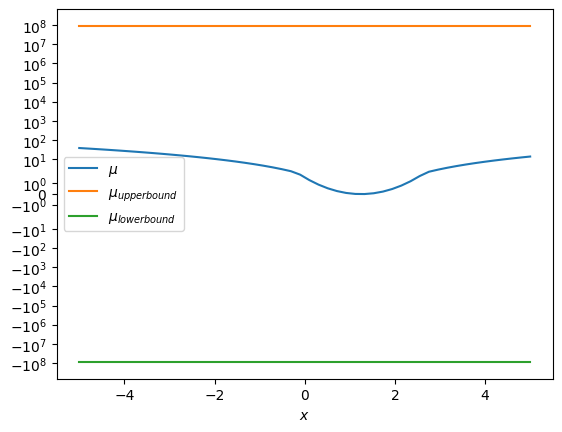

In [24]:
X = np.linspace(l, u)
muX = gp_model.mean(X).flatten()
import matplotlib.pyplot as plt
plt.plot(X, muX, label=r'$\mu$')
plt.plot(X, mu_U * np.ones(len(X)), label=r'$\mu_{upper bound}$')
plt.plot(X, mu_L * np.ones(len(X)), label=r'$\mu_{lower bound}$')
plt.yscale('symlog')
plt.xlabel(r'$x$')
plt.legend()
plt.show()

In [5]:
import numpy as np
from dataclasses import dataclass

import numpy as np
from scipy.stats import qmc  # already used by Problem

acq_type = "EI"

problem = QuadraticShift(nx, c=c)
problem.set_constraints([])  # <-- no constraints for this test
x_train = problem.sample(n_samples)
y_train = problem.evaluate(x_train)

gp_model = smtKRG(theta, problem.xlimits, nx)
gp_model.train(x_train, y_train)
print(f"GP model trained with theta = {theta}")
        
solver_options = {"max_iter": 500, "print_level": 2}
options = {
          'log_level': 'info',
          'acquisition_type': acq_type,
          'acquisition_method': 'bnb',
          'bo_maxiter': 10,
          'opt_solver': 'IPOPT',
          'solver_options': solver_options,
     }

bo = BOAlgorithm(problem, gp_model, x_train, y_train, options=options)
bo.optimize()

if hasattr(bo, "best_x"):
    dist = np.linalg.norm(bo.best_x - problem.x_star)
    print(f"[Check] ||x_best - x*|| = {dist:.3e}  (x* = {problem.x_star})")

hiopbbpy Problem name: QuadraticShift
hiopbbpy Max BO iter: 10
hiopbbpy Optimizing acquisition (EI) with 10 random initial points
hiopbbpy Batch type: KB
hiopbbpy Batch size: 1
hiopbbpy Internal optimization solver: IPOPT
hiopbbpy Internal optimization solver options: {'max_iter': 500, 'print_level': 2, 'sb': 'yes'}
hiopbbpy Initial training set: 5 samples, 1 dimensions
hiopbbpy Logger level: info
hiopbbpy Best UNCONSTRAINED objective from 5 initial samples: 4.1518e-02 
hiopbbpy Best CONSTRAINED objective from 5 feasible initial samples: 4.1518e-02
hiopbbpy *****************************
hiopbbpy Iteration 1/10
hiopbbpy In batch 1/1
hiopbbpy Start finding the best sampling point:


GP model trained with theta = 0.01
corr =  pow_exp
p =  2.0
=== Starting Branch & Bound Optimization (Minimization) ===
Initial bounds: l = [-5.], u = [5.]
Number of points: 5, Dim = 1
Polishing not needed - no active set detected at optimal point
l =  [-5.]
u =  [5.]

Initial acquisition lower bound: -54097333.28216237
Initial acquisition upper bound: -0.0

--- Iteration 1 ---
Node bounds: l=[-5.], u=[5.]
Node acquisition bounds: L=-54097333.28216237, U=-0.0
Current best feasible value (GUB): -0.0
  Branching to child: l=[-5.], u=[0.]
Polishing not needed - no active set detected at optimal point
l =  [-5.]
u =  [0.]
  Child acquisition bounds: L=-46186492.73155274, U=-0.0
  Branching to child: l=[0.], u=[5.]
Polishing not needed - no active set detected at optimal point
l =  [0.]
u =  [5.]
  Child acquisition bounds: L=-37065377.33731221, U=-0.0
Queue size: 2 | GLB=-46186492.73155274 | GUB=-0.0 | Gap=46186492.73155274

--- Iteration 2 ---
Node bounds: l=[-5.], u=[0.]
Node acquisition

ValueError: matmul: Input operand 1 does not have enough dimensions (has 0, gufunc core with signature (n?,k),(k,m?)->(n?,m?) requires 1)